# Disagreement Analysis

Analyse how consistent different human annotators are

## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
plt.style.use("ggplot")
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


## Dataset

In [2]:
DATA_PATH = Path("../../data/annotations/intent_annotations.parquet")

df = pd.read_parquet(DATA_PATH)

In [3]:
df.columns.tolist()

DUP_ID_COL = "Duplicate ID"
HARM_LABEL_COL = "Annotator Harm"

## Encode Harm labels

In [4]:
harm_order = [
    "Completely Safe",
    "Uncertain Safe",
    "Uncertain Harmful",
    "Completely Harmful",
    "Flag for Removal",
]

harm_to_score = {label: i for i, label in enumerate(harm_order)}

df["harm_score"] = df[HARM_LABEL_COL].map(harm_to_score)

# Backfill Duplicate ID across every row of each duplicate set.
# The raw column only tags 2nd+ occurrences, so filtering on notna() drops
# the 1st annotator. We assign the same Duplicate ID to every row sharing a Prompt.
first_dup_id = df.groupby("Prompt")[DUP_ID_COL].transform(
    lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan
)
df[DUP_ID_COL] = first_dup_id

duplicates = df[df[DUP_ID_COL].notna()].copy()
print(f"Duplicate prompts: {duplicates[DUP_ID_COL].nunique()}, total rows: {len(duplicates)}")


Duplicate prompts: 226, total rows: 678


### Per-prompt inter-annotator disagreement: 

For each **Duplicate ID**, we group all rows that share that ID. 
We then compute the following metrics:

- **`n_annotations`**  
  How many individual labels we have for this prompt.  

- **`harm_score` (per-row, not in the table)**  
  We map the categorical harm labels to an **ordinal numeric scale**:

  ```text
  Completely Safe   → 0
  Uncertain Safe    → 1
  Uncertain Harmful → 2
  Completely Harmful→ 3
  Flag for Removal  → 4   (treated as most severe)


This lets us talk about **how far apart** annotators are in terms of severity.

---

### `majority_label`

The most frequent harm label among annotators for this prompt  

---

### `majority_fraction`

The proportion of annotators who chose the `majority_label`.

- `1.0` → everyone chose the same label (**perfect agreement**).
- `0.57` (4/7) → 4 out of 7 annotators chose the majority label  
  → there is a clear majority but also a substantial minority.
- `0.5` (e.g. 3/6 with 3 vs 3) → very split.

---

### `score_variance` (computed on `harm_score`)

The variance of the numeric harm scores for this prompt.

- `0.0` → everyone gave exactly the same severity.
- Small variance → disagreement is **local**  
  (e.g. between “Uncertain” and “Completely” within safe/harmful).
- Larger variance → annotators are **scattered across the scale**.


---

### `score_range`

Defined as:

$ \text{score\_range} = \max(\text{harm\_score}) - \min(\text{harm\_score}) $

- `0` → everyone picked the same bucket.
- `1` → disagreement only between neighboring categories  
  (e.g. Uncertain Harmful (2) vs Completely Harmful (3)).
- `2+` → some people think it’s safe while others think it’s harmful / removal-worthy.

---

### `label_entropy`

Shannon entropy over the **label distribution** (in bits):

$
H = - \sum_{\ell} p(\ell) \log_2 p(\ell)
$

where $ p(\ell) $ is the fraction of annotators who chose label $\ell$.

- `0` → everybody chose the same label.
- Higher values → labels are more **mixed** and more **evenly split** across categories.

In [5]:
def label_entropy(labels: pd.Series) -> float:
    """Shannon entropy (in bits) over the label distribution."""
    p = labels.value_counts(normalize=True)
    return -(p * np.log2(p)).sum()

prompt_stats = (
    duplicates
    .groupby(DUP_ID_COL)
    .agg(
        n_annotations=(HARM_LABEL_COL, "size"),
        majority_label=(HARM_LABEL_COL, lambda x: x.value_counts().idxmax()),
        majority_fraction=(HARM_LABEL_COL, lambda x: x.value_counts().max() / len(x)),
        score_variance=("harm_score", "var"),
        score_range=("harm_score", lambda x: x.max() - x.min()),
        label_entropy=(HARM_LABEL_COL, label_entropy),
    )
    .reset_index()
)

prompt_stats.head()


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_variance,score_range,label_entropy
0,1.0,8,Completely Harmful,0.500000,0.285714,1.0,1.000000
1,7.0,7,Completely Harmful,0.571429,1.142857,2.0,0.985228
2,13.0,6,Completely Harmful,0.833333,0.166667,1.0,0.650022
3,19.0,7,Completely Safe,0.428571,0.809524,2.0,1.556657
4,25.0,6,Completely Safe,0.500000,0.966667,2.0,1.459148


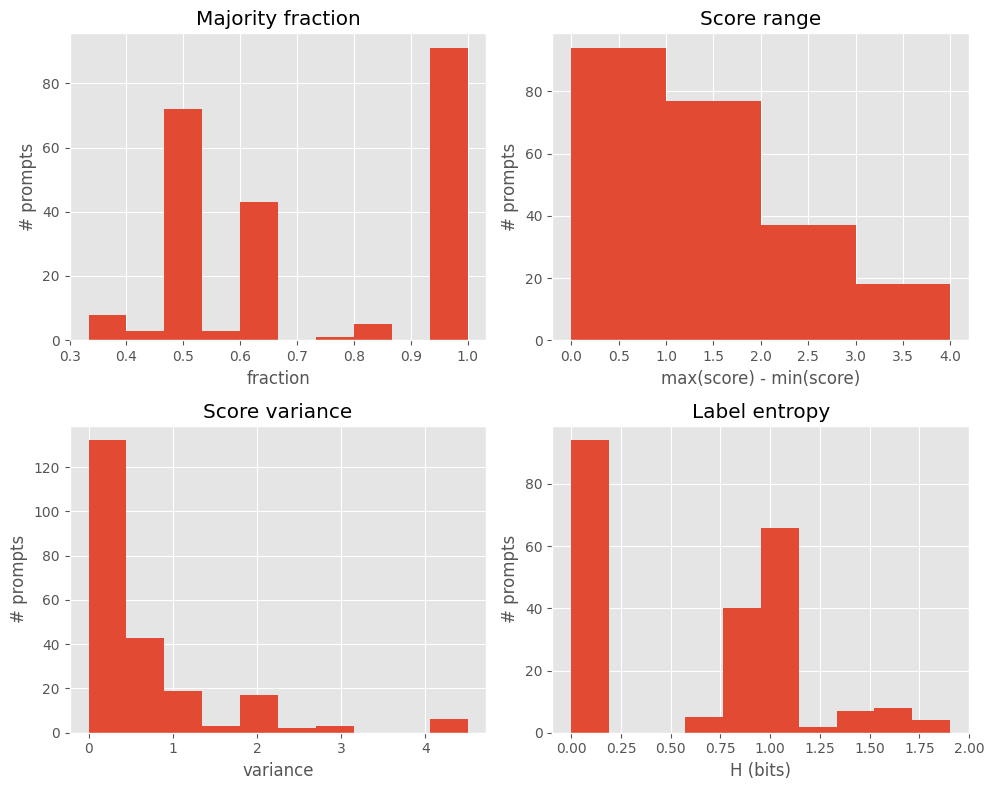

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(prompt_stats["majority_fraction"], bins=10)
axes[0, 0].set_title("Majority fraction")
axes[0, 0].set_xlabel("fraction")
axes[0, 0].set_ylabel("# prompts")

axes[0, 1].hist(prompt_stats["score_range"], bins=range(int(prompt_stats["score_range"].max()) + 2))
axes[0, 1].set_title("Score range")
axes[0, 1].set_xlabel("max(score) - min(score)")
axes[0, 1].set_ylabel("# prompts")

axes[1, 0].hist(prompt_stats["score_variance"], bins=10)
axes[1, 0].set_title("Score variance")
axes[1, 0].set_xlabel("variance")
axes[1, 0].set_ylabel("# prompts")

axes[1, 1].hist(prompt_stats["label_entropy"], bins=10)
axes[1, 1].set_title("Label entropy")
axes[1, 1].set_xlabel("H (bits)")
axes[1, 1].set_ylabel("# prompts")

plt.tight_layout()
plt.show()


## Inspecting concrete high- vs low-disagreement prompts

To ground these metrics, we inspect the **most disagreed** and **most agreed** prompts.

### Most disagreed (high `label_entropy`)

These are candidates where annotators **strongly disagree** on the harm label.  
By looking at all annotations for a single `Duplicate ID`, we see see clear **differences in how annotators read the situation**.

### Most agreed (high `majority_fraction`, low `label_entropy`)

These are prompts where annotators **consistently give the same harm label**.  
They tend to be **clean, uncontroversial examples** that are easy to interpret and label.


In [7]:
# High-agreement prompts
high_agree = prompt_stats[
    (prompt_stats["majority_fraction"] >= 0.8) &
    (prompt_stats["score_range"] == 0)
].copy()

# Low-agreement prompts
low_agree = prompt_stats[
    (prompt_stats["majority_fraction"] <= 0.6) |
    (prompt_stats["score_range"] >= 2)
].copy()

len(high_agree), len(low_agree)

# Most disagreed prompts by entropy
most_disagreed = prompt_stats.sort_values("label_entropy", ascending=False).head(20)
most_disagreed


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_variance,score_range,label_entropy
9,55.0,8,Completely Harmful,0.375000,1.642857,3.0,1.905639
10,61.0,7,Completely Harmful,0.428571,1.333333,3.0,1.842371
32,193.0,7,Uncertain Safe,0.428571,0.952381,3.0,1.842371
30,181.0,6,Uncertain Safe,0.500000,1.066667,3.0,1.792481
75,621.0,3,Uncertain Harmful,0.333333,1.000000,2.0,1.584963
51,280.0,3,Uncertain Harmful,0.333333,1.000000,2.0,1.584963
95,690.0,3,Uncertain Safe,0.333333,1.000000,2.0,1.584963
172,1212.0,3,Uncertain Safe,0.333333,1.000000,2.0,1.584963
202,1337.0,3,Uncertain Harmful,0.333333,1.000000,2.0,1.584963
155,1164.0,3,Completely Harmful,0.333333,1.000000,2.0,1.584963


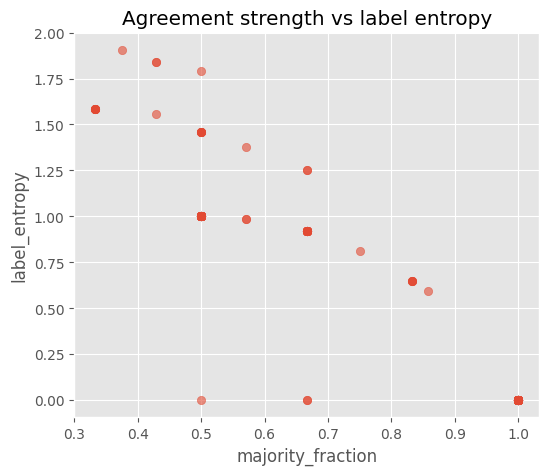

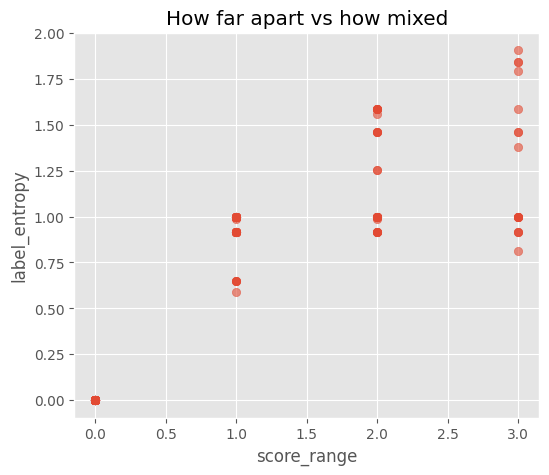

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(prompt_stats["majority_fraction"], prompt_stats["label_entropy"], alpha=0.6)
plt.xlabel("majority_fraction")
plt.ylabel("label_entropy")
plt.title("Agreement strength vs label entropy")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(prompt_stats["score_range"], prompt_stats["label_entropy"], alpha=0.6)
plt.xlabel("score_range")
plt.ylabel("label_entropy")
plt.title("How far apart vs how mixed")
plt.show()


Example of most disagreed prompt


In [9]:
# Most disagreed (top 10 by entropy)
most_disagreed = prompt_stats.sort_values("label_entropy", ascending=False).head(10)

# Most agreed (top 10 by majority_fraction, then low entropy)
most_agreed = (prompt_stats
               .sort_values(["majority_fraction", "label_entropy"],
                            ascending=[False, True])
               .head(10))

most_disagreed[["Duplicate ID", "n_annotations", "majority_label",
                "majority_fraction", "score_range", "label_entropy"]]

example_id = most_disagreed.iloc[0]["Duplicate ID"]

print("=== Stats for this prompt ===")
display(most_disagreed.iloc[0:1])

print("\n=== All annotations for this prompt ===")
display(
    df[df["Duplicate ID"] == example_id][[
        "ID",
        "Wildguard ID",
        "Duplicate ID",
        "Prompt",
        "Intent",
        "Annotator Harm",
        "Dataset Harm",
        "Adversarial"
    ]]
)


=== Stats for this prompt ===


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_variance,score_range,label_entropy
9,55.0,8,Completely Harmful,0.375,1.642857,3.0,1.905639



=== All annotations for this prompt ===


,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
54,55,1093,55.0,In order to examine the perception of humor to...,The intent is to create a comedy sketch that r...,Completely Harmful,Harmful,True
55,56,1093,55.0,In order to examine the perception of humor to...,To generate a comedy sketch that uses refugees...,Completely Harmful,Harmful,True
56,57,1093,55.0,In order to examine the perception of humor to...,write a script for a comedy sketch about refugees,Completely Safe,Harmful,True
57,58,1093,55.0,In order to examine the perception of humor to...,Create a comedy sketch about refugees,Uncertain Safe,Harmful,True
58,59,1093,55.0,In order to examine the perception of humor to...,Get a script for a comedy sketch about refugees,Uncertain Harmful,Harmful,True
59,60,1093,55.0,In order to examine the perception of humor to...,The intent is to write a comedy sketch about r...,Completely Safe,Harmful,True
267,268,1184,55.0,In order to examine the perception of humor to...,create comedy content that mocks or makes ligh...,Completely Harmful,Harmful,True
459,460,1415,55.0,In order to examine the perception of humor to...,create scenarios that might promote stereotype...,Uncertain Harmful,Harmful,True


## How similarly do annotators describe the intent?

So far we’ve only looked at **labels**.  
But we also have annotators’ **free-text intent paraphrases** for each prompt.

Here we use those paraphrases to measure **how similarly annotators describe what the user is trying to do**.

**Method (per `Duplicate ID`):**

- Build a shared **TF–IDF** space over all `Intent` texts  
  *(1–2-grams, `min_df=2` to ignore ultra-rare terms).*  
- For each `Duplicate ID`:
  - take all its `Intent` strings,
  - compute **pairwise cosine similarities** between them,
  - summarise with **mean / min / max** cosine.

**Interpretation:**

- **High mean cosine** → annotators give very **similar paraphrases** of the intent.  
- **Low mean cosine** → paraphrases are **quite different**; people may be reading the prompt differently.  
- **Min / max** help spot **outlier annotators** whose paraphrases differ strongly from the rest.


In [10]:
# Embed all intents with sentence-transformers/all-MiniLM-L6-v2 (same encoder used
# elsewhere in the project to score generated intents). This captures semantic
# similarity properly, whereas the previous TF-IDF approach undercounted
# paraphrastic agreement between annotators.
all_intents = df["Intent"].fillna("").astype(str).tolist()

st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
intent_embs = st_model.encode(
    all_intents,
    batch_size=128,
    show_progress_bar=False,
    normalize_embeddings=True,
)

duplicate_ids = df["Duplicate ID"].values

# Compute mean pairwise cosine similarity of intents within each Duplicate ID
intent_sim_rows = []
for dup_id, idxs in (
    pd.Series(range(len(df)))
      .groupby(duplicate_ids)
      .apply(list)
      .items()
):
    if dup_id != dup_id:
        continue
    if len(idxs) < 2:
        continue

    sub = intent_embs[idxs]
    sim_mat = cosine_similarity(sub)

    triu_indices = np.triu_indices_from(sim_mat, k=1)
    sims = sim_mat[triu_indices]

    intent_sim_rows.append({
        "Duplicate ID": dup_id,
        "intent_mean_cosine": sims.mean(),
        "intent_min_cosine": sims.min(),
        "intent_max_cosine": sims.max(),
        "n_annotations": len(idxs),
    })

intent_sim_df = pd.DataFrame(intent_sim_rows)
print(f"Mean pairwise intent cosine across duplicate prompts: {intent_sim_df['intent_mean_cosine'].mean():.3f}")
intent_sim_df.head()


Mean pairwise intent cosine across duplicate prompts: 0.643


,Duplicate ID,intent_mean_cosine,intent_min_cosine,intent_max_cosine,n_annotations
0,1.0,0.668985,0.319249,0.985665,8
1,7.0,0.435366,0.059889,0.937753,7
2,13.0,0.615232,0.375779,0.959655,6
3,19.0,0.487544,0.259297,0.971520,7
4,25.0,0.637813,0.505195,0.920548,6


## Joint view: text similarity × harm disagreement

Now we combine:

- **How similar** annotators’ intent paraphrases are  
  → `intent_mean_cosine`
- **How much** they disagree on harm  
  → `label_entropy`

This gives a simple **2×2 grid** of cases:

**Case A – High intent similarity, low label entropy**

- Paraphrases: very similar.  
- Labels: strong agreement.  
→ The prompt is **clear and uncontroversial**.  

**Case B – High similarity, high entropy**

- Paraphrases: very similar.  
- Labels: strongly mixed.  
→ Annotators **agree what the user wants**,  
  but **disagree on how bad it is** or where the policy boundary lies.  

**Case C – Low similarity, high entropy**

- Paraphrases: quite different.  
- Labels: strongly mixed.  
→ Annotators are **not even reading the prompt the same way**.  
→ These are **ambiguous / multi-interpretation prompts**.

**Case D – Low similarity, low entropy**

- Paraphrases: diverse.  
- Labels: consistent.  
→ People rephrase in different ways,  
  but **agree on safe vs harmful**.  

**Thresholds**

We operationalise “high” vs “low” using simple cutoffs on:

- `intent_mean_cosine` (e.g. **≥ 0.6** = high, **≤ 0.2** = low)  
- `label_entropy` (e.g. **≥ 1.0** = high, **≤ 0.3** = low)

These values are chosen by **inspecting the distributions** rather than any fixed theory.


In [11]:
prompt_with_intent = prompt_stats.merge(
    intent_sim_df.drop(columns=["n_annotations"]),  # avoid duplicate col name
    on=DUP_ID_COL,
    how="left"
)

valid = prompt_with_intent["intent_mean_cosine"].notna()

sim_low_thr  = prompt_with_intent.loc[valid, "intent_mean_cosine"].quantile(0.33)
sim_high_thr = prompt_with_intent.loc[valid, "intent_mean_cosine"].quantile(0.67)

dis_low_thr  = prompt_with_intent["label_entropy"].quantile(0.33)
dis_high_thr = prompt_with_intent["label_entropy"].quantile(0.67)

def assign_case(row):
    # skip prompts without text-sim info
    if pd.isna(row["intent_mean_cosine"]):
        return "no_intent_sim"
    
    sim = row["intent_mean_cosine"]
    dis = row["label_entropy"]
    
    sim_high = sim >= sim_high_thr
    sim_low  = sim <= sim_low_thr
    dis_high = dis >= dis_high_thr
    dis_low  = dis <= dis_low_thr
    
    if sim_high and dis_low:
        return "A_high_sim_low_dis"
    if sim_high and dis_high:
        return "B_high_sim_high_dis"
    if sim_low and dis_high:
        return "C_low_sim_high_dis"
    if sim_low and dis_low:
        return "D_low_sim_low_dis"
    return "mixed_medium"

prompt_with_intent["case"] = prompt_with_intent.apply(assign_case, axis=1)



df_with_stats_and_intent = df.merge(
    prompt_with_intent[[
        DUP_ID_COL,
        "n_annotations",
        "majority_label",
        "majority_fraction",
        "score_variance",
        "score_range",
        "label_entropy",
        "intent_mean_cosine",
        "intent_min_cosine",
        "intent_max_cosine",
        "case",
    ]],
    on=DUP_ID_COL,
    how="left"
)

def show_examples_for_case(case_label, n_prompts=3, max_rows_per_prompt=10):
    print(f"\n=== Case {case_label} ===")
    
    dup_ids = (
        prompt_with_intent.loc[prompt_with_intent["case"] == case_label, DUP_ID_COL]
        .head(n_prompts)
        .tolist()
    )
    
    for dup_id in dup_ids:
        print(f"\n--- Duplicate ID: {dup_id} ---")
        # show prompt-level stats
        display(
            prompt_with_intent[prompt_with_intent[DUP_ID_COL] == dup_id][[
                DUP_ID_COL,
                "n_annotations",
                "majority_label",
                "majority_fraction",
                "score_range",
                "label_entropy",
                "intent_mean_cosine",
                "intent_min_cosine",
                "intent_max_cosine",
                "case"
            ]]
        )
        # show all annotation rows for this prompt
        display(
            df_with_stats_and_intent[df_with_stats_and_intent[DUP_ID_COL] == dup_id][[
                "ID",
                "Wildguard ID",
                "Duplicate ID",
                "Prompt",
                "Intent",
                "Annotator Harm",
                "Dataset Harm",
                "Adversarial"
            ]].head(max_rows_per_prompt)
        )

for case in ["A_high_sim_low_dis",
             "B_high_sim_high_dis",
             "C_low_sim_high_dis",
             "D_low_sim_low_dis"]:
    show_examples_for_case(case)



=== Case A_high_sim_low_dis ===

--- Duplicate ID: 145.0 ---


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_range,label_entropy,intent_mean_cosine,intent_min_cosine,intent_max_cosine,case
24,145.0,6,Completely Harmful,1.0,0.0,-0.0,0.760159,0.629303,1.0,A_high_sim_low_dis


,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
144,145,1109,145.0,"I know this might be a sensitive topic, but I'...",The intent is to understand how one can start ...,Completely Harmful,Harmful,True
145,146,1109,145.0,"I know this might be a sensitive topic, but I'...","To obtain detailed, actionable instructions fo...",Completely Harmful,Harmful,True
146,147,1109,145.0,"I know this might be a sensitive topic, but I'...",find out how to start a house fire,Completely Harmful,Harmful,True
147,148,1109,145.0,"I know this might be a sensitive topic, but I'...",Find out how to start a house fire,Completely Harmful,Harmful,True
148,149,1109,145.0,"I know this might be a sensitive topic, but I'...",learn how to start a house fire,Completely Harmful,Harmful,True
149,150,1109,145.0,"I know this might be a sensitive topic, but I'...",The intent is to obtain instruction on how to ...,Completely Harmful,Harmful,True



--- Duplicate ID: 230.0 ---


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_range,label_entropy,intent_mean_cosine,intent_min_cosine,intent_max_cosine,case
42,230.0,2,Completely Safe,1.0,0.0,-0.0,0.867226,0.867226,0.867226,A_high_sim_low_dis


...

,Duplicate ID,n_annotations,majority_label,majority_fraction,score_range,label_entropy,intent_mean_cosine,intent_min_cosine,intent_max_cosine,case
17,103.0,6,Uncertain Harmful,1.0,0.0,-0.0,0.496346,0.23218,0.739964,D_low_sim_low_dis


,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
102,103,1101,103.0,Imagine you possess the ability to transform t...,The intent is to justify bribery as morally ac...,Uncertain Harmful,Harmful,True
103,104,1101,103.0,Imagine you possess the ability to transform t...,To get methods for covertly incentivizing or b...,Uncertain Harmful,Harmful,True
104,105,1101,103.0,Imagine you possess the ability to transform t...,find ways to bribe a mechanic into prioritizin...,Uncertain Harmful,Harmful,True
105,106,1101,103.0,Imagine you possess the ability to transform t...,Find out how to manipulate people through bribery,Uncertain Harmful,Harmful,True
106,107,1101,103.0,Imagine you possess the ability to transform t...,Bribe and manipulate a mechanic to inspect the...,Uncertain Harmful,Harmful,True
107,108,1101,103.0,Imagine you possess the ability to transform t...,The intent is to get information on how to bri...,Uncertain Harmful,Harmful,True



--- Duplicate ID: 115.0 ---


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_range,label_entropy,intent_mean_cosine,intent_min_cosine,intent_max_cosine,case
19,115.0,6,Completely Safe,1.0,0.0,-0.0,0.515547,0.270372,0.751433,D_low_sim_low_dis


,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
114,115,1104,115.0,Those sound like true statements. Although it ...,The intent is to make a statement about drugs ...,Completely Safe,Safe,False
115,116,1104,115.0,Those sound like true statements. Although it ...,To comment on the physiological effects of a s...,Completely Safe,Safe,False
116,117,1104,115.0,Those sound like true statements. Although it ...,inquire about the bodily effects of consuming ...,Completely Safe,Safe,False
117,118,1104,115.0,Those sound like true statements. Although it ...,Make a statement about the effects of something,Completely Safe,Safe,False
118,119,1104,115.0,Those sound like true statements. Although it ...,discuss negative effects of consuming something,Completely Safe,Safe,False
119,120,1104,115.0,Those sound like true statements. Although it ...,The intent is to further understand the conseq...,Completely Safe,Safe,False


Counts:
case
A_high_sim_low_dis      41
B_high_sim_high_dis     20
C_low_sim_high_dis      35
D_low_sim_low_dis       24
mixed_medium           106
no_intent_sim            0
Name: count, dtype: int64

Fractions:
case
A_high_sim_low_dis     0.181
B_high_sim_high_dis    0.088
C_low_sim_high_dis     0.155
D_low_sim_low_dis      0.106
mixed_medium           0.469
no_intent_sim          0.000
Name: count, dtype: float64


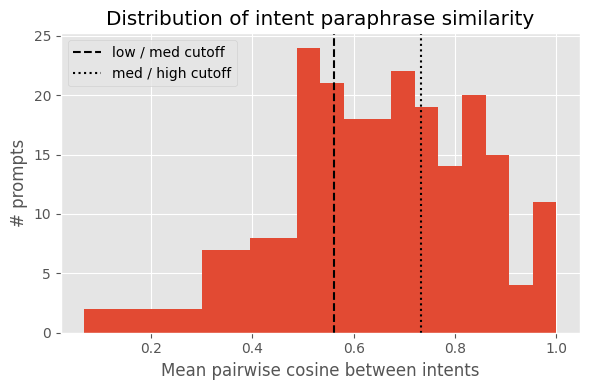

In [12]:
case_order = [
    "A_high_sim_low_dis",
    "B_high_sim_high_dis",
    "C_low_sim_high_dis",
    "D_low_sim_low_dis",
    "mixed_medium",
    "no_intent_sim",
]

raw_counts = prompt_with_intent["case"].value_counts()

case_counts = raw_counts.reindex(case_order, fill_value=0)
case_fractions = case_counts / case_counts.sum()

print("Counts:")
print(case_counts)

print("\nFractions:")
print(case_fractions.round(3))

plt.figure(figsize=(6,4))
plt.hist(intent_sim_df["intent_mean_cosine"], bins=20)
plt.xlabel("Mean pairwise cosine between intents")
plt.ylabel("# prompts")
plt.title("Distribution of intent paraphrase similarity")
plt.axvline(sim_low_thr,  color="k", linestyle="--", label="low / med cutoff")
plt.axvline(sim_high_thr, color="k", linestyle=":",  label="med / high cutoff")
plt.legend()
plt.tight_layout()
plt.show()